# Local expmnation of noun phrases of VLM
### Step 1: Generate the concept matix uning the features of noun phrase
### Step 2: Run an inference with an image or without an image. get all the embedding of the noun phrases
### Step 3: Select one embedding corresponds to the noun phrase of step 2 
### Step 4: Project the embedding to the concept matrix and get the corresponding images
### Step 5: Select random images from the concept matrix and ask VLM to describe the images and get the noun phrases from them.


## Generate Concept matrix

In [2]:
#Generate hidden states for Qwen2-VL-7B-Instruct on COCO dataset
concept_example = 'parachute'

save_file_name = f"qwen2_image_concept_hidden_states_{concept_example.replace(' ', '_')}"
data_dir =  f"/mnt/abka03/crops/train/{concept_example.replace(' ', '_')}"

!export HF_HOME=/mnt/abka03/huggingface/hub


!cd ../ && python src/save_features.py \
    --model_name "Qwen/Qwen2-VL-7B-Instruct" \
    --dataset_name "image" \
    --dataset_size "300" \
    --data_dir $data_dir \
    --hook_name  "save_hidden_states_noun_phrase" \
    --modules_to_hook "model.norm" \
    --save_dir "/mnt/abka03/xl-vlms" \
    --save_filename $save_file_name \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --exact_match_modules_to_hook \
    --concept "{concept_example}" \
    --cache_dir "/mnt/abka03/xl-vlms/cache"


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-05-14 15:08:26,852 - INFO - Loading model: Qwen/Qwen2-VL-7B-Instruct
2025-05-14 15:08:26,852 - INFO - Arguments:
2025-05-14 15:08:26,853 - INFO - seed: 0
2025-05-14 15:08:26,853 - INFO - model_name_or_path: Qwen/Qwen2-VL-7B-Instruct
2025-05-14 15:08:26,853 - INFO - processor_name: None
2025-05-14 15:08:26,853 - INFO - local_files_only: False
2025-05-14 15:08:26,853 - INFO - cache_dir: /mnt/abka03/xl-vlms/cache
2025-05-14 15:08:26,853 - INFO - prompt_template: llava
2025-05-14 15:08:26,853 - INFO - prompt: Describe the image in detail.
2025-05-14 15:08:26,853 - INFO - data_dir: /mnt/abka03/xlvlm_data/coco_50_samples/train_all
2025-05-14 15:08:26,853 - INFO - annotation_file: annotations.json
2025-05-14 15:08:26,853 - INFO - questions_file: annotations.json
2025-05-14 15:08:26,853 - INFO - answer_type_to_answer: None
2025-05-14 15:08:26,853 - INFO - split: train
2025

In [9]:
# Geneate concept vectors for Qwen2-VL-7B-Instruct on COCO dataset
concept_example = "garbage truck"
!export HF_HOME=/mnt/abka03/huggingface/hub


# Need to specify analysis type. This will decompose features, and extract both text, visual grounding
!analysis_name=decompose_activations_text_grounding_image_grounding

# Specify path where you have saved features on training data
saved_features_path=f"/mnt/abka03/concept_extraction/features/save_hidden_states_noun_phrase_qwen2_image_concept_hidden_states_{concept_example.replace(' ', '_')}.pth"

# Where to store details about extracted concepts. Default directory is results/
results_filename=f"phrase_embeddings_concepts_{concept_example.replace(' ', '_')}" # Name of the file to save the results

# Specify the specific feature module you want to decompose

# LLaVA-v1.5
#feature_module=language_model.model.norm
#feature_module=language_model.model.layers.30

# Molmo-7B
#feature_module=model.transformer.blocks.27
#feature_module=model.transformer.ln_f
save_dir="/mnt/abka03/concept_robust"
# Idefics2-8B
#feature_module=model.text_model.norm

# Qwen2-VL-7B
feature_module="model.norm"


decomposition="snmf" # Current options: snmf, kmeans, pca, simple
n_concepts=2# Size of dictionary learnt i.e. number of concepts

!cd ../ && python src/analyse_features.py \
--model_name  "Qwen/Qwen2-VL-7B-Instruct"  \
--analysis_name "decompose_activations_text_grounding_image_grounding" \
--features_path $saved_features_path \
--module_to_decompose $feature_module \
--num_concepts $n_concepts \
--decomposition_method $decomposition \
--save_filename $results_filename \
--save_dir $save_dir


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-05-13 19:33:38,588 - INFO - Arguments:
2025-05-13 19:33:38,588 - INFO - seed: 0
2025-05-13 19:33:38,588 - INFO - model_name_or_path: Qwen/Qwen2-VL-7B-Instruct
2025-05-13 19:33:38,588 - INFO - processor_name: None
2025-05-13 19:33:38,588 - INFO - local_files_only: False
2025-05-13 19:33:38,588 - INFO - cache_dir: None
2025-05-13 19:33:38,588 - INFO - prompt_template: llava
2025-05-13 19:33:38,588 - INFO - prompt: Describe the image in detail.
2025-05-13 19:33:38,589 - INFO - data_dir: data/
2025-05-13 19:33:38,589 - INFO - annotation_file: annotations.json
2025-05-13 19:33:38,589 - INFO - questions_file: annotations.json
2025-05-13 19:33:38,589 - INFO - answer_type_to_answer: None
2025-05-13 19:33:38,589 - INFO - split: train
2025-05-13 19:33:38,589 - INFO - dataset_size: -1
2025-05-13 19:33:38,589 - INFO - dataset_name: coco
2025-05-13 19:33:38,589 - INFO - batch_s

## Visualize concept set

In [10]:
# Import libraries to visualize the results
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import matplotlib
import pydicom
from PIL import Image
import numpy as np
import os
import torch
print("Matplotlib version for info:", matplotlib.__version__)

Matplotlib version for info: 3.9.4


dict_keys(['concepts', 'activations', 'decomposition_method', 'text_grounding', 'image_grounding_paths', 'analysis_model'])


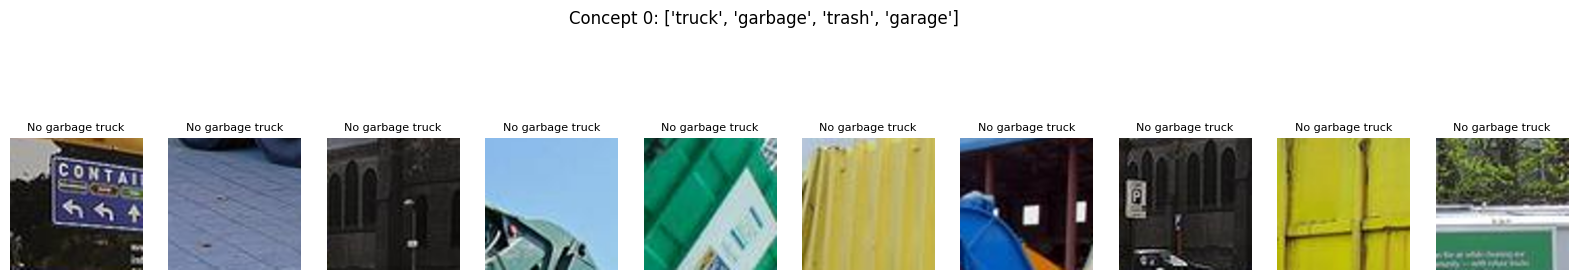

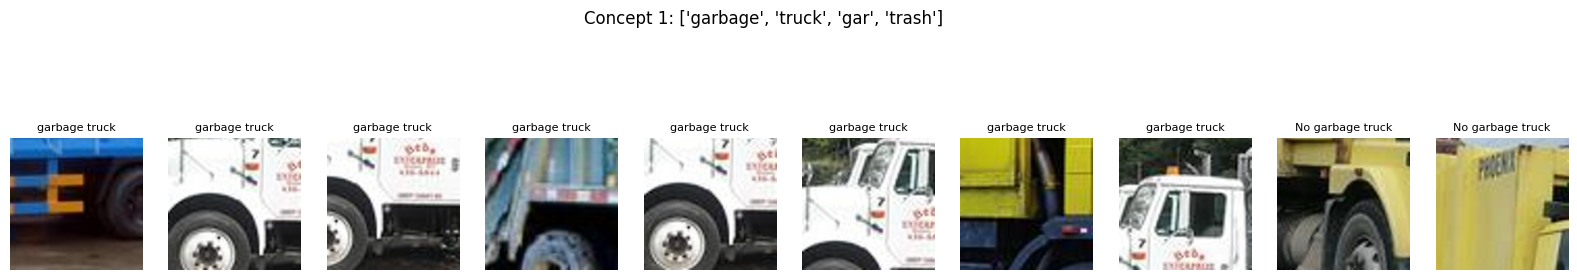

In [12]:

num_concepts = 2 # Number of concepts to visualize
results_filename = "/mnt/abka03/concept_robust/decompose_activations_text_grounding_image_grounding_phrase_embeddings_concepts_charch.pth" # Path to the results file for concept embeddings
results_filename = "/mnt/abka03/concept_robust/decompose_activations_text_grounding_image_grounding_phrase_embeddings_concepts_garbage_truck.pth"# Path to the results file for concept embeddings
concept_data = torch.load(results_filename)
print(concept_data.keys())
concept_image = concept_data["image_grounding_paths"]
concept_text = concept_data['text_grounding']
def load_image(file_path):
    """
    Load an image file (.dcm, .jpeg, .png).

    Parameters:
        file_path (str): The path to the image file.

    Returns:
        numpy.ndarray: The loaded image as a NumPy array.
    """
    # Extract the file extension
    ext = os.path.splitext(file_path)[-1].lower()

    if ext == ".dcm":
        # Load DICOM file
        dicom_data = pydicom.dcmread(file_path)
        image = dicom_data.pixel_array
        return image

    elif ext in [".jpeg", ".jpg", ".png"]:
        # Load JPEG or PNG file
        image = Image.open(file_path)
        return np.array(image)

    else:
        raise ValueError(f"Unsupported file format: {ext}")


def visualize_grounding(concept_idx, concept_text, image_paths):
    concept_names = concept_text[concept_idx]
    paths = image_paths[concept_idx]
    num_imgs = len(paths)
    images = []
    for path in paths:
        concept,path = path.split("@")
    
        concept_names.append(concept)
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)
    width = num_imgs*2+0.1
    fig = plt.figure(figsize=(width, width/5))
    for i in range(num_imgs):
        fig.add_subplot(1, num_imgs, i+1)
        plt.imshow(images[i])
        plt.axis('off')
    fig.suptitle('Concept ' + str(concept_idx) + ': ' + str(concept_names)) 


def visualize_grounding(concept_idx, concept_text, image_paths):
    concept_names = concept_text[concept_idx]
    paths = image_paths[concept_idx]
    num_imgs = len(paths)
    images = []
    concept_list = []

    for path in paths:
        concept, path = path.split("@")
        concept_list.append(concept)
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)

    width = num_imgs * 2 + 0.1
    fig = plt.figure(figsize=(width, width / 5))

    for i in range(num_imgs):
        ax = fig.add_subplot(1, num_imgs, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
        ax.set_title(concept_list[i], fontsize=8)  # Adding concept names below each image

    fig.suptitle('Concept ' + str(concept_idx) + ': ' + str( concept_names))
    plt.show()


for k in range(num_concepts):
    visualize_grounding(k, concept_text, concept_image)

## Local Explantion

In [3]:
# Get the feature for one image 
concept_example = 'petrol pump' #{concept_example.replace(' ', '_')}
image = f"/mnt/abka03/imagenette2-320/val/gas_station/n03425413_3471.JPEG"
#image = "/mnt/abka03/Projects/xl-vlms/playground/dataset/recipe-desktop-merkts-cheesy-hot-dawg.jpg"
!cd ../ && python src/save_features.py \
    --model_name "Qwen/Qwen2-VL-7B-Instruct" \
    --dataset_name "image" \
    --data_dir $image \
    --hook_name  "save_hidden_states_noun_phrase" \
    --modules_to_hook "model.norm" \
    --save_dir "/mnt/abka03/xl-vlms" \
    --save_filename "qwen2_image_coco_hidden_states" \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --exact_match_modules_to_hook \
    --concept "{concept_example}" \
    --cache_dir "/mnt/abka03/xl-vlms/cache"

[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-05-14 21:56:06,261 - INFO - Loading model: Qwen/Qwen2-VL-7B-Instruct
2025-05-14 21:56:06,262 - INFO - Arguments:
2025-05-14 21:56:06,262 - INFO - seed: 0
2025-05-14 21:56:06,262 - INFO - model_name_or_path: Qwen/Qwen2-VL-7B-Instruct
2025-05-14 21:56:06,262 - INFO - processor_name: None
2025-05-14 21:56:06,262 - INFO - local_files_only: False
2025-05-14 21:56:06,262 - INFO - cache_dir: /mnt/abka03/xl-vlms/cache
2025-05-14 21:56:06,262 - INFO - prompt_template: llava
2025-05-14 21:56:06,262 - INFO - prompt: Describe the image in detail.
2025-05-14 21:56:06,262 - INFO - data_dir: /mnt/abka03/imagenette2-320/val/gas_station/n03425413_3471.JPEG
2025-05-14 21:56:06,262 - INFO - annotation_file: annotations.json
2025-05-14 21:56:06,262 - INFO - questions_file: annotations.json
2025-05-14 21:56:06,262 - INFO - answer_type_to_answer: None
2025-05-14 21:56:06,262 - INFO - sp

In [61]:
# Project the image to the concept and explain 

import sys



script_path = "/mnt/abka03/Projects/xl-vlms/src"
if script_path not in sys.path:
    sys.path.append(script_path)

from analysis.feature_decomposition import get_feature_matrix
module_name = "model.norm"
token_idx = None
output = torch.load("/mnt/abka03/xl-vlms/features/save_hidden_states_noun_phrase_qwen2_image_coco_hidden_states.pth")
absolute_features = output["hidden_states"]

feat_matrix = get_feature_matrix(
            absolute_features,
            module_name=module_name,
            token_idx=token_idx,
        )



phrase_and_text_prediction = output["model_predictions"]
phrases = [out[0].split("@")[0] for out in phrase_and_text_prediction]
print("Model predcition is: ", output["model_predictions"][0][0].split("@")[0])
print("Phrases are: ", phrases)

test_image_file_name = output["image"]



Model predcition is:  Petrol pump
Phrases are:  ['Petrol pump']


In [62]:
# project the image feature to concepts
import analysis.feature_decomposition as analysis_decomposition
analysis_model = concept_data["analysis_model"]
grounding_words = concept_data["text_grounding"]
#projections = analysis_decomposition.project_test_sample(
#        sample=feat_matrix,
#        analysis_model=analysis_model,
#       decomposition_type=concept_data["decomposition_method"],
#    )

# Diectly multiply the activations
feat_matrix = feat_matrix.float()
print(feat_matrix.type(), concept_data["concepts"].T.type())
projections = feat_matrix @ concept_data["concepts"].T
print(projections.shape)

import numpy as np

def find_top_n_powerful_projection(data, n):
    """
    Finds the top n elements for each row along with their indices.

    Parameters:
    - data: List of lists or 2D numpy array.
    - n: Number of top values to find.

    Returns:
    - A list of lists, where each sublist contains tuples of (index, value) 
      representing the top n elements and their indices for the corresponding row.
    """
    # Ensure the input is a numpy array
    data = np.array(data)
    
    # Get the top n indices and values for each row
    top_n_indices = [np.argsort(row)[-n:][::-1] for row in data]
    top_n_pairs = [[(idx, row[idx]) for idx in idxs] for row, idxs in zip(data, top_n_indices)]
    
    return top_n_pairs

n = 6 #mumber of concept to discover 
top_powerful_indexes = find_top_n_powerful_projection(projections, n)

def remap_prjection_image_text(top_powerful_indexes, test_image_path, image_concept_path, phrase_concept_path, text_concept_path):
    if len(top_powerful_indexes) != len(test_image_path):
        raise ValueError("The projection list and image list of test data not have equal number.")
    
    print("Image concept path:",len(test_image_path))
    final_result = {}
    for each_image_path, concept_indexs in zip(test_image_path, top_powerful_indexes, ):
        final_result[each_image_path[0]] = {'vis_concepts':[(image_concept_path[i[0]], i[1]) for i in concept_indexs], 'phrase_concept': [phrase_concept_path[i[0]] for i in concept_indexs],  'text_concept': [( text_concept_path[i[0]],i[1]) for i in concept_indexs]}

    return final_result


image_grounding_paths = concept_data["image_grounding_paths"]
phrase_grounding_paths = concept_data['image_grounding_paths']
text_grounding_paths = concept_data["text_grounding"]
test_data_remapped = remap_prjection_image_text(top_powerful_indexes, test_image_file_name, image_grounding_paths, phrase_grounding_paths, text_grounding_paths)



def load_image_as_rgb(filepath):
    """
    Load an image (DICOM, PNG, JPG) and return its RGB data as a NumPy array.

    Args:
        filepath (str): Path to the image file.

    Returns:
        np.ndarray: RGB data as a NumPy array.
    """
    # Check file extension
    file_ext = filepath.split(".")[-1].lower()

    if file_ext in ["png", "jpg", "jpeg"]:
        # For PNG or JPG, use Pillow
        image = Image.open(filepath).convert("RGB")  # Ensure it's RGB
        return np.array(image).astype(np.uint8)

    elif file_ext == "dcm":
        # For DICOM, use pydicom
        dicom_file = pydicom.dcmread(filepath)

        # Apply modality LUT if necessary to get pixel values
        image_data = apply_modality_lut(dicom_file.pixel_array, dicom_file)

        # Normalize to 0-255 for RGB conversion (if necessary)
        if np.max(image_data) > 255:
            image_data = (image_data / np.max(image_data)) * 255.0

        # Convert grayscale to RGB (if it's single-channel)
        if len(image_data.shape) == 2:  # Grayscale image
            image_data = np.stack([image_data] * 3, axis=-1)  # Convert to RGB

        return image_data.astype(np.uint8)

    else:
        raise ValueError(f"Unsupported file format: {file_ext}")


def visualize_local_explantion(concept_idx, text_grounding, image_paths):
    words = text_grounding[concept_idx]
    paths = image_paths[concept_idx][0]
    importance = image_paths[concept_idx][1]
    num_imgs = len(paths)
    images = []
    phrases = []
    for path in paths:
        phr, im_path = path.split('@')
        cur_img = load_image_as_rgb(im_path)
        phrases.append(phr)
        images.append(cur_img)
    width = num_imgs*2+0.1
    fig = plt.figure(figsize=(width, width/5))
    for i in range(num_imgs):
        ax = fig.add_subplot(1, num_imgs, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
        ax.set_title(phrases[i], fontsize=8) 
    fig.suptitle('Concept ' + str(concept_idx) + ': ' + str([word.split("@")[0] for word in words[0]]) + 'vis_importance: ' + str(round(importance.item()))) 


def local_explantion(a_test_image,test_data_remapped):
    
# Provide the file path to the image
    image_path = a_test_image.split("@")[1]

    # Read and display the image
    img = load_image_as_rgb(image_path)
    fig = plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap="gray")
    plt.axis('off')  # Optional: Turn off the axis
    plt.show()
    key = a_test_image
    text_concepts = test_data_remapped[key]
    for i in range(n):
         visualize_local_explantion(i, text_concepts['text_concept'], text_concepts['vis_concepts'] )


torch.FloatTensor torch.FloatTensor
torch.Size([1, 10])
Image concept path: 1


In [63]:
test_image = test_image_file_name
print("All phrases:", test_image)


All phrases: [['Petrol pump@/mnt/abka03/imagenette2-320/val/gas_station/n03425413_3471.JPEG']]


Phrase at image: Petrol pump@/mnt/abka03/imagenette2-320/val/gas_station/n03425413_3471.JPEG


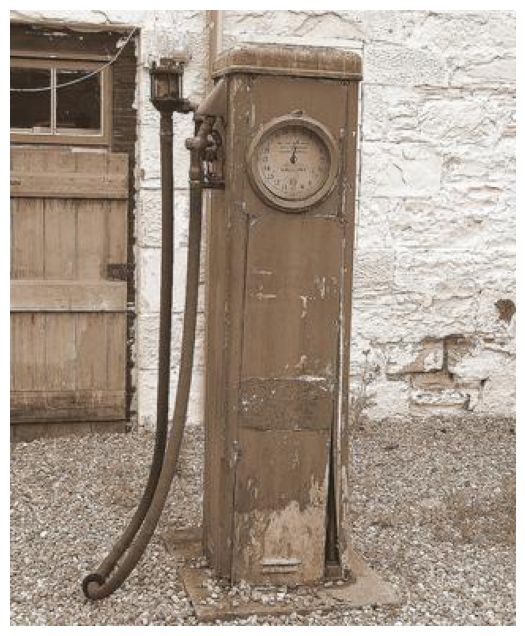

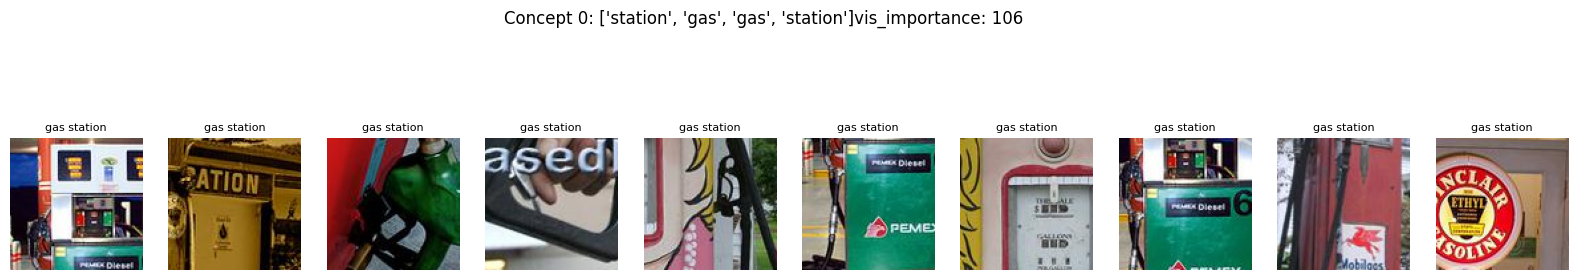

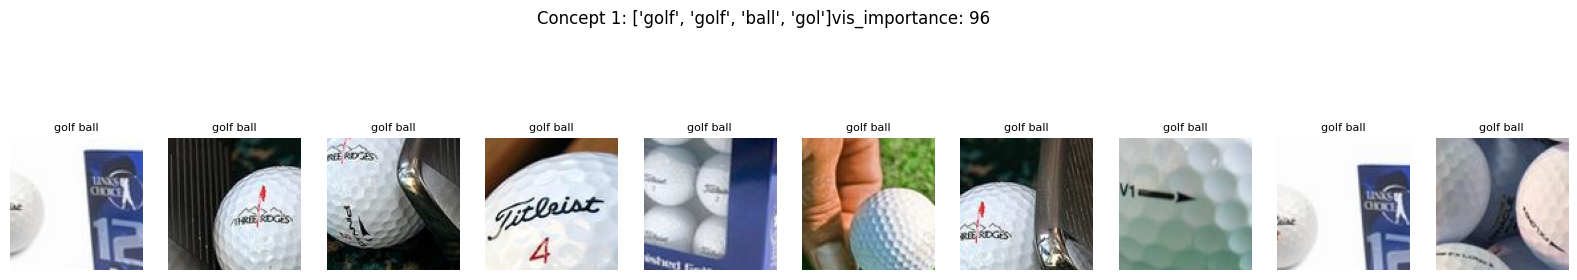

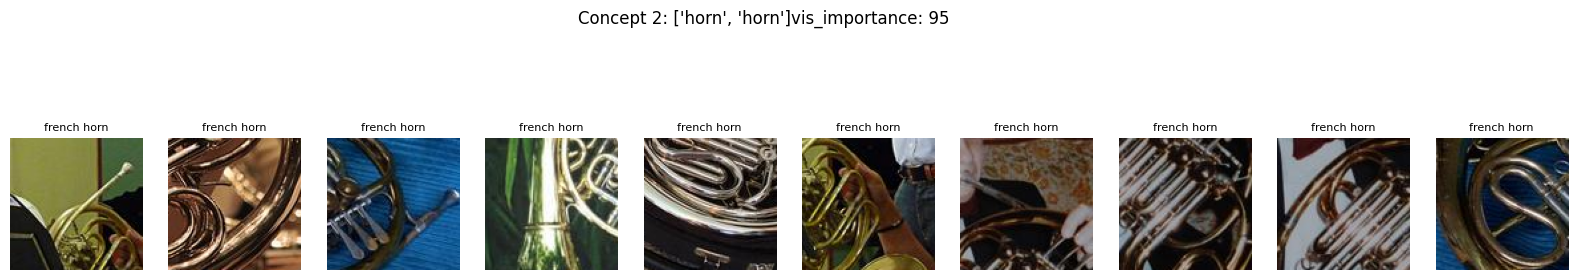

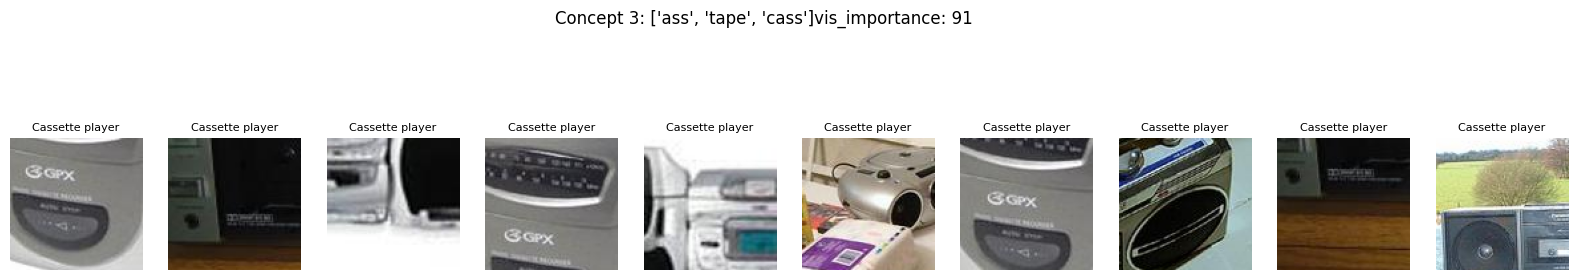

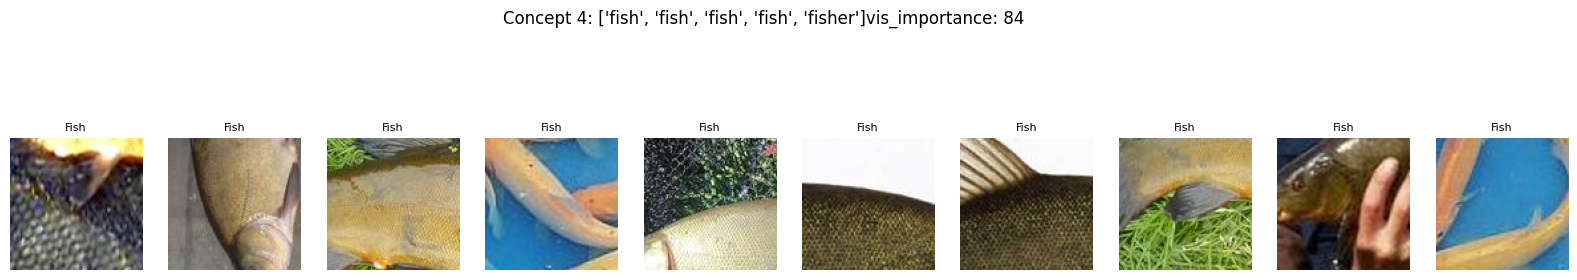

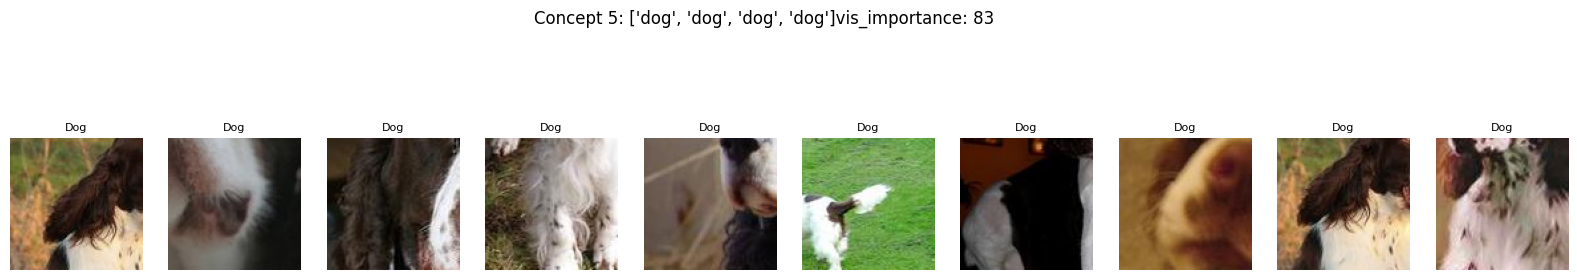

In [64]:
#explain one noun phrase
phrase_number = 0
a_test_phrase_with_image = test_image[phrase_number][0]
print("Phrase at image:", a_test_phrase_with_image)
local_explantion(a_test_phrase_with_image, test_data_remapped )

## Explain text with images in vlm.
### We have the image concepts

### First get the embedding for a text 



In [261]:
# Get the feature for one image 

!cd ../ && python src/save_features.py \
    --model_name "Qwen/Qwen2-VL-7B-Instruct" \
    --dataset_name "text" \
    --data_dir "a charch" \
    --hook_name  "save_hidden_states_noun_phrase" \
    --modules_to_hook "model.norm" \
    --save_dir "/mnt/abka03/xl-vlms" \
    --save_filename "qwen2_text_hidden_states" \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --exact_match_modules_to_hook \
    --cache_dir "/mnt/abka03/xl-vlms/cache"

10827.52s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-05-10 00:04:25,236 - INFO - Loading model: Qwen/Qwen2-VL-7B-Instruct
2025-05-10 00:04:25,236 - INFO - Arguments:
2025-05-10 00:04:25,236 - INFO - seed: 0
2025-05-10 00:04:25,236 - INFO - model_name_or_path: Qwen/Qwen2-VL-7B-Instruct
2025-05-10 00:04:25,236 - INFO - processor_name: None
2025-05-10 00:04:25,236 - INFO - local_files_only: False
2025-05-10 00:04:25,236 - INFO - cache_dir: /mnt/abka03/xl-vlms/cache
2025-05-10 00:04:25,236 - INFO - prompt_template: llava
2025-05-10 00:04:25,236 - INFO - prompt: Describe the image in detail.
2025-05-10 00:04:25,236 - INFO - data_dir: a charch
2025-05-10 00:04:25,236 - INFO - annotation_file: annotations.json
2025-05-10 00:04:25,236 - INFO - questions_file: annotations.json
2025-05-10 00:04:25,236 - INFO - answer_type_to_answer: None
2025-05-10 00:04:25,236 - INFO - split: train
2025-05-10 00:04:25,236 - INFO - dataset_siz

In [262]:
text_feature_path = "/mnt/abka03/xl-vlms/features/save_hidden_states_noun_phrase_qwen2_text_hidden_states.pth"
output = torch.load(text_feature_path)
#print(output)
absolute_features = output["hidden_states"]
print(output["model_predictions"])



[["'a charch'"]]


torch.FloatTensor torch.FloatTensor
torch.Size([1, 10])
Test cocept text: 1
All text: [["'a charch'"]]
Phrase at image: 'a charch'


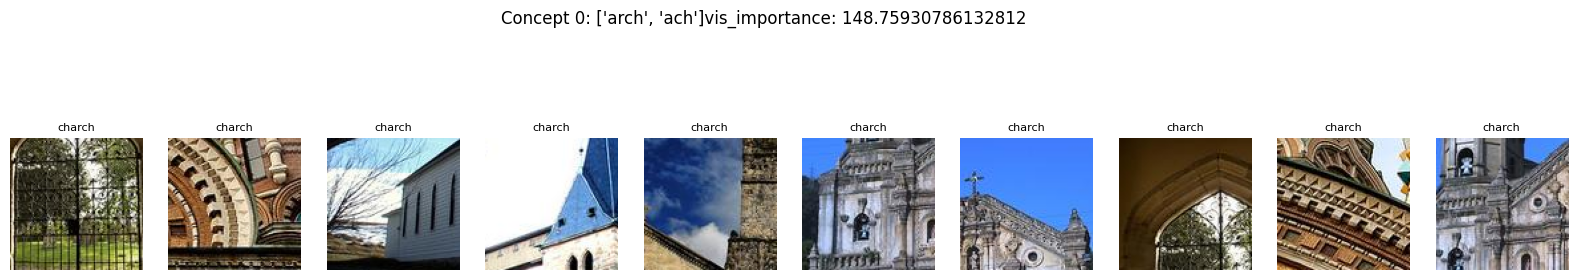

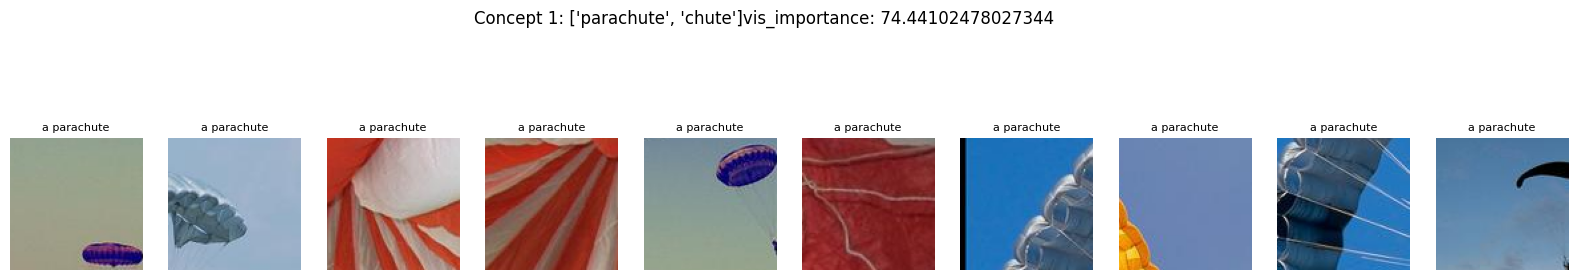

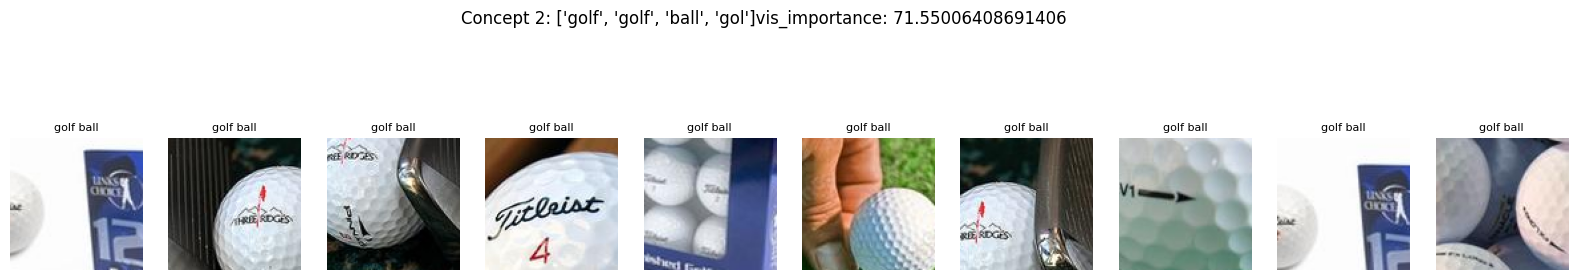

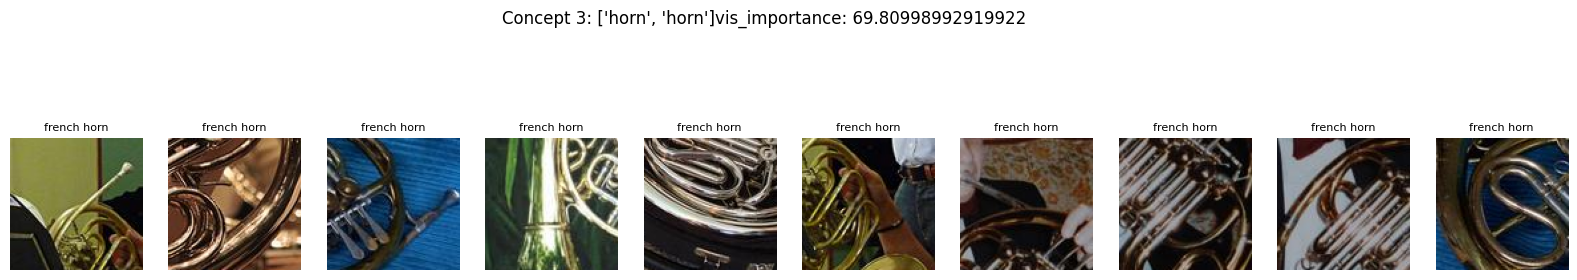

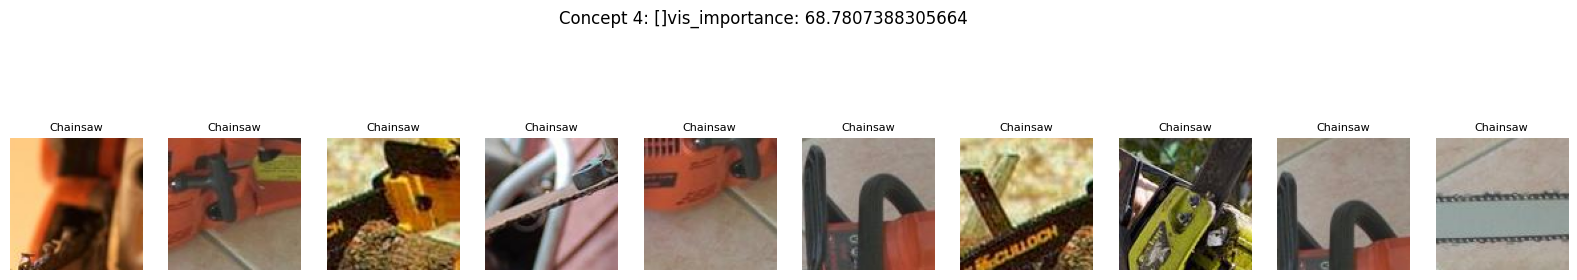

In [263]:
# Project the text in to the concept and explain
script_path = "/mnt/abka03/Projects/xl-vlms/src"
if script_path not in sys.path:
    sys.path.append(script_path)

from analysis.feature_decomposition import get_feature_matrix
module_name = 'model.norm'
token_idx = None
output = torch.load(text_feature_path)
absolute_features = output["hidden_states"]
feat_matrix = get_feature_matrix(
            absolute_features,
            module_name=module_name,
            token_idx=token_idx,
        )

import analysis.feature_decomposition as analysis_decomposition
analysis_model = concept_data["analysis_model"]
grounding_words = concept_data["text_grounding"]
#projections = analysis_decomposition.project_test_sample(
#        sample=feat_matrix,
#        analysis_model=analysis_model,
#       decomposition_type=concept_data["decomposition_method"],
#   )

feat_matrix = feat_matrix.float()
print(feat_matrix.type(), concept_data["concepts"].T.type())
projections = feat_matrix @ concept_data["concepts"].T

print(projections.shape)
top_powerful_indexes = find_top_n_powerful_projection(projections, n)
test_text = output['model_predictions']
def remap_prjection_text(top_powerful_indexes, test_text, image_concept_path,  text_concept_path):
    if len(top_powerful_indexes) != len(test_text):
        raise ValueError("The projection list and image list of test data not have equal number.")
    
    print("Test cocept text:",len(test_text))
    final_result = {}
    for each_image_path, concept_indexs in zip(test_text, top_powerful_indexes):
        final_result[each_image_path[0]] = {'vis_concepts':[(image_concept_path[i[0]], i[1]) for i in concept_indexs],  'text_concept': [( text_concept_path[i[0]],i[1]) for i in concept_indexs]}

    return final_result


text_grounding_paths = concept_data["text_grounding"]
test_data_remapped_text = remap_prjection_text(top_powerful_indexes, test_text , image_grounding_paths, text_grounding_paths)
def visualize_grounding_text(concept_idx, text_grounding, image_paths):
    words = text_grounding[concept_idx]
    paths = image_paths[concept_idx][0]
    importance = image_paths[concept_idx][1]
    num_imgs = len(paths)
    images = []
    phrases = []
    for path in paths:
        phr, cur_img = path.split('@')
        cur_img = load_image_as_rgb(cur_img)
        phrases.append(phr)
        #cur_img = np.array(cur_img.resize([256, 256]))
        images.append(cur_img)
    width = num_imgs*2+0.1
    fig = plt.figure(figsize=(width, width/5))
    for i in range(num_imgs):
        ax = fig.add_subplot(1, num_imgs, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
        ax.set_title(phrases[i], fontsize=8) 
    fig.suptitle('Concept ' + str(concept_idx) + ': ' + str(words[0]) + 'vis_importance: ' + str(importance.item()))  
n=5
def local_explantion_text(a_test_image,test_data_remapped):
    
# Provide the file path to the image
    #image_path = a_test_image.split("@")[1]

    # Read and display the image
    #img = load_image_as_rgb(image_path)
    #fig = plt.figure(figsize=(8, 8))
    #plt.imshow(img, cmap="gray")
    #plt.axis('off')  # Optional: Turn off the axis
    #plt.show()
    #key = a_test_image
    text_concepts = test_data_remapped[a_test_image]
    for i in range(n):
         visualize_grounding_text(i, text_concepts['text_concept'], text_concepts['vis_concepts'] )
test_text = output['model_predictions']
print("All text:", test_text)
#explain one noun phrase
phrase_number = 0
a_test_phrase_with_image = test_text[phrase_number][0]
print("Phrase at image:", a_test_phrase_with_image)
local_explantion_text(a_test_phrase_with_image, test_data_remapped_text )

